# Comparaison 6 modèles — CWRU Bearing Dataset — by_fault_type

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_fault_type : Ball → Inner Race → Outer Race (3 tâches) |
| **Modèles** | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | CWRU Bearing Dataset (CWRU) — 9 features statistiques |
| **Sprint** | 12 — S12-07 |

Ce notebook agrège les résultats des expériences **exp_074, exp_075, exp_076, exp_077, exp_078, exp_079**.

**Figures générées** :
1. `comparison_aa_af_bwt.png` — Barplot groupé AA/AF/BWT (6 modèles)
2. `scatter_af_vs_ram.png` — Scatter AF vs RAM (trade-off oubli/contrainte embarquée)
3. `ranking_models.png` — Ranking par score composite (AA − AF)

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "cwru_by_fault_type":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import plot_metrics_comparison, save_figure

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/cwru/by_fault_type"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES  = ["Ball", "Inner Race", "Outer Race"]
MODEL_ORDER = ["EWC", "HDC", "TinyOL", "KMeans", "Mahalanobis", "DBSCAN"]
RAM_BUDGET  = 65_536

MODEL_EXP_MAP = {
    "EWC":         "exp_074_ewc_cwru_by_fault_type",
    "HDC":         "exp_075_hdc_cwru_by_fault_type",
    "TinyOL":      "exp_076_tinyol_cwru_by_fault_type",
    "KMeans":      "exp_077_kmeans_cwru_by_fault_type",
    "Mahalanobis": "exp_078_mahalanobis_cwru_by_fault_type",
    "DBSCAN":      "exp_079_dbscan_cwru_by_fault_type",
}

BASELINE_EXP_MAP = {
    "EWC":         "exp_068_ewc_cwru_single_task",
    "HDC":         "exp_069_hdc_cwru_single_task",
    "TinyOL":      "exp_070_tinyol_cwru_single_task",
    "KMeans":      "exp_071_kmeans_cwru_single_task",
    "Mahalanobis": "exp_072_mahalanobis_cwru_single_task",
    "DBSCAN":      "exp_073_dbscan_cwru_single_task",
}


def load_acc_matrix(raw_mat: list, ragged: bool = False) -> np.ndarray:
    mat = np.full((3, 3), np.nan, dtype=float)
    for i, row in enumerate(raw_mat):
        for j, v in enumerate(row):
            if v is not None:
                mat[i, j] = v
    return mat


BASE = REPO_ROOT / "experiments"
results     = {}
acc_matrices = {}
baselines   = {}

for model in MODEL_ORDER:
    exp_dir = BASE / MODEL_EXP_MAP[model] / "results"
    metrics_path = exp_dir / "metrics_cl.json"
    if not metrics_path.exists():
        print(f"⚠️  {MODEL_EXP_MAP[model]} non disponible — mock activé")
        results[model] = {"aa": 0.0, "af": 0.0, "bwt": 0.0,
                          "ram_peak_bytes": 0, "inference_latency_ms": 0.0,
                          "n_params": 0, "per_task_acc": [0.0, 0.0, 0.0]}
        acc_matrices[model] = np.zeros((3, 3))
        continue
    raw = json.loads(metrics_path.read_text())
    # Schéma plat uniforme pour CWRU
    results[model] = {
        "aa":  raw["acc_final"],
        "af":  raw["avg_forgetting"],
        "bwt": raw["backward_transfer"],
        "ram_peak_bytes":      raw["ram_peak_bytes"],
        "inference_latency_ms": raw["inference_latency_ms"],
        "n_params": raw["n_params"],
        "per_task_acc": raw["per_task_acc"],
    }
    acc_matrices[model] = load_acc_matrix(raw["acc_matrix"])

    # Baseline single-task
    bline_path = BASE / BASELINE_EXP_MAP[model] / "results" / "metrics_single_task.json"
    if bline_path.exists():
        braw = json.loads(bline_path.read_text())
        baselines[model] = braw.get("accuracy") or braw.get("acc_final", float("nan"))
    else:
        baselines[model] = float("nan")

    r = results[model]
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms n={r['n_params']}")

print(f"\n6 modèles chargés | {datetime.now():%Y-%m-%d %H:%M}")

EWC          → AA=1.0000 AF=0.0000 BWT=+0.0000 RAM=  1.1Ko lat=0.02033ms n=865
HDC          → AA=0.9351 AF=0.0455 BWT=-0.0390 RAM=  7.7Ko lat=0.05211ms n=1024
TinyOL       → AA=0.9664 AF=0.0019 BWT=+0.0065 RAM=  4.0Ko lat=0.00524ms n=397
KMeans       → AA=0.1515 AF=0.0195 BWT=+0.0390 RAM=  5.3Ko lat=0.16130ms n=18
Mahalanobis  → AA=0.3160 AF=0.0130 BWT=+0.2857 RAM=  1.6Ko lat=0.00417ms n=90
DBSCAN       → AA=0.1255 AF=0.0455 BWT=-0.0455 RAM= 16.4Ko lat=0.12908ms n=1116

6 modèles chargés | 2026-04-26 16:13


In [2]:
# Section 2 — Tableau comparatif AA / AF / BWT / RAM / latence

RAM_LIMIT = 65_536
header = "| Modèle | AA ↑ | AF ↓ | BWT | RAM | Latence | n_params | Baseline ST |"
sep    = "|--------|:----:|:----:|:---:|:---:|:-------:|:--------:|:-----------:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b = r["ram_peak_bytes"]
    ram_s = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_LIMIT else ''}"
    bst   = baselines.get(model, float("nan"))
    bst_s = f"{bst:.4f}" if not (isinstance(bst, float) and bst != bst) else "—"
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{ram_s} | {r['inference_latency_ms']:.5f} ms | {r['n_params']} | {bst_s} |"
    )
    rows.append(line)

display(Markdown("### Tableau comparatif — 6 modèles CL (cwru/by_fault_type)\n\n" + "\n".join(rows)))

### Tableau comparatif — 6 modèles CL (cwru/by_fault_type)

| Modèle | AA ↑ | AF ↓ | BWT | RAM | Latence | n_params | Baseline ST |
|--------|:----:|:----:|:---:|:---:|:-------:|:--------:|:-----------:|
| EWC | 1.0000 | 0.0000 | +0.0000 | 1.1 Ko | 0.02033 ms | 865 | 0.9783 |
| HDC | 0.9351 | 0.0455 | -0.0390 | 7.7 Ko | 0.05211 ms | 1024 | 0.8870 |
| TinyOL | 0.9664 | 0.0019 | +0.0065 | 4.0 Ko | 0.00524 ms | 397 | 0.9000 |
| KMeans | 0.1515 | 0.0195 | +0.0390 | 5.3 Ko | 0.16130 ms | 18 | 0.1587 |
| Mahalanobis | 0.3160 | 0.0130 | +0.2857 | 1.6 Ko | 0.00417 ms | 90 | 0.1391 |
| DBSCAN | 0.1255 | 0.0455 | -0.0455 | 16.4 Ko | 0.12908 ms | 1116 | 0.1457 |

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/cwru/by_fault_type/comparison_aa_af_bwt.png


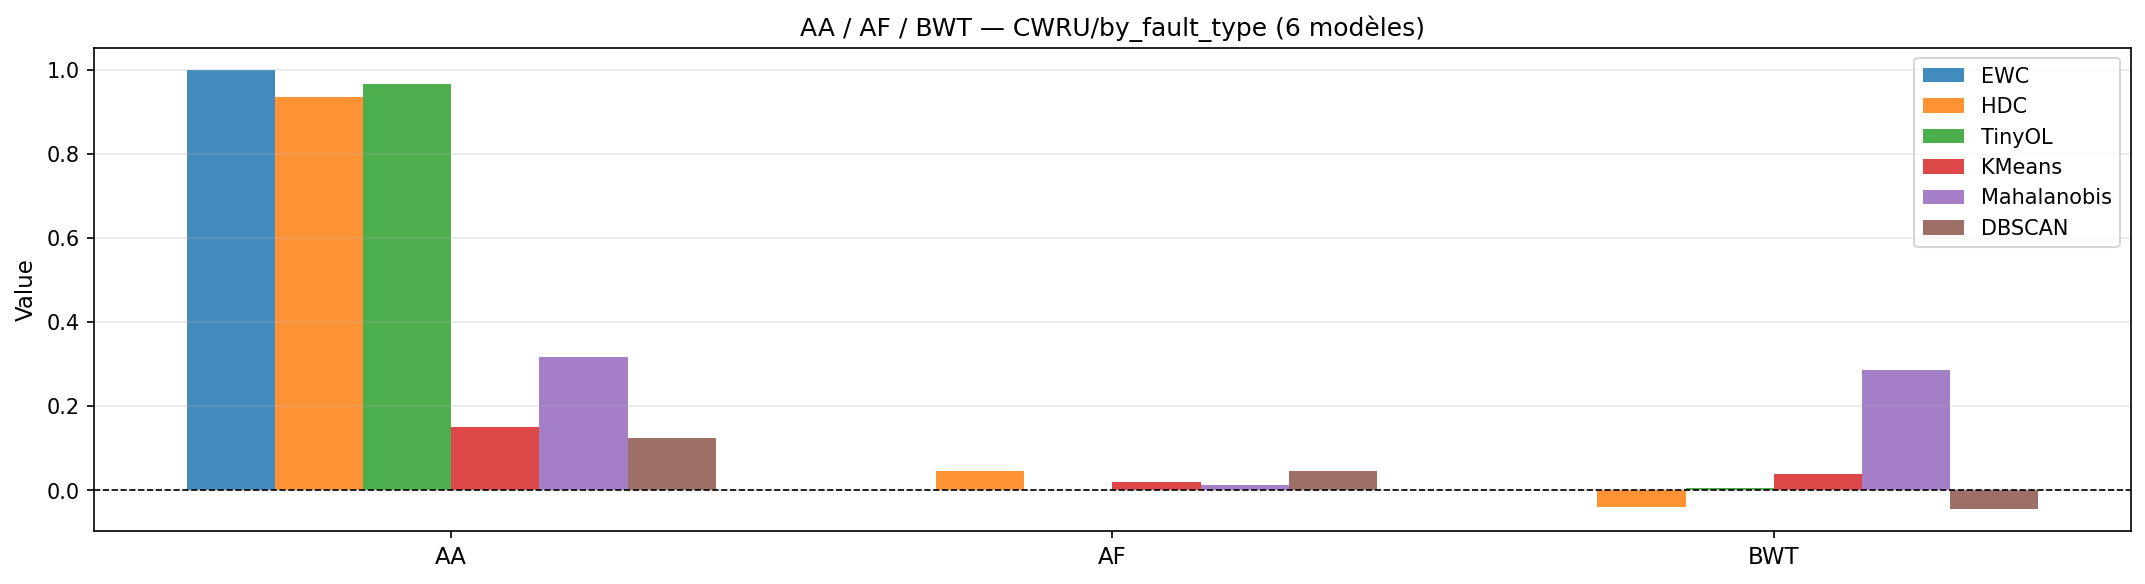

In [3]:
# Section 3 — Barplot groupé AA / AF / BWT (6 modèles) → comparison_aa_af_bwt.png

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — CWRU/by_fault_type (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "comparison_aa_af_bwt.png")
display(Image(str(FIGURES_DIR / "comparison_aa_af_bwt.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/cwru/by_fault_type/scatter_af_vs_ram.png


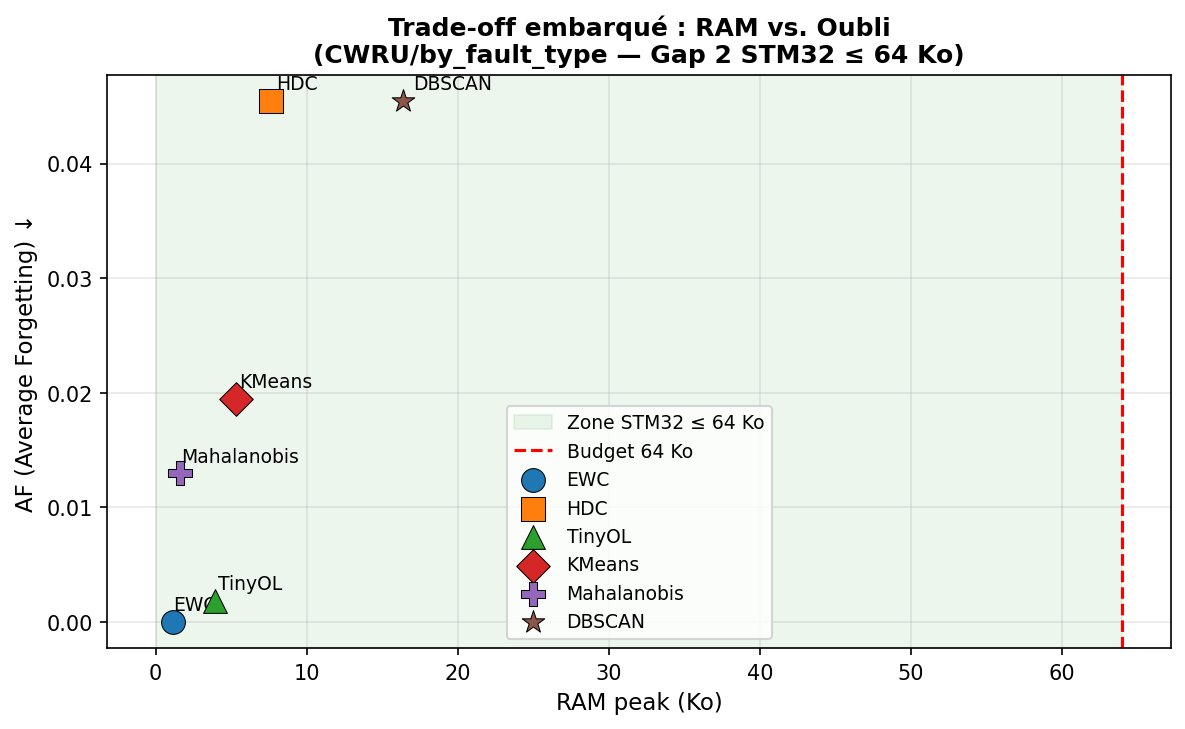

In [4]:
# Section 4 — Scatter AF vs RAM (trade-off oubli / contrainte embarquée) → scatter_af_vs_ram.png

SCATTER_MARKERS = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, RAM_BUDGET / 1024, alpha=0.07, color="green", label=f"Zone STM32 ≤ 64 Ko")
ax.axvline(RAM_BUDGET / 1024, color="red", linestyle="--", linewidth=1.5, label="Budget 64 Ko")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    af_val = r["af"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, af_val, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(ram_kb, af_val), xytext=(ram_kb * 1.04, af_val + 0.001), fontsize=9)

ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AF (Average Forgetting) ↓", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. Oubli\n(CWRU/by_fault_type — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_af_vs_ram.png")
display(Image(str(FIGURES_DIR / "scatter_af_vs_ram.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/cwru/by_fault_type/ranking_models.png


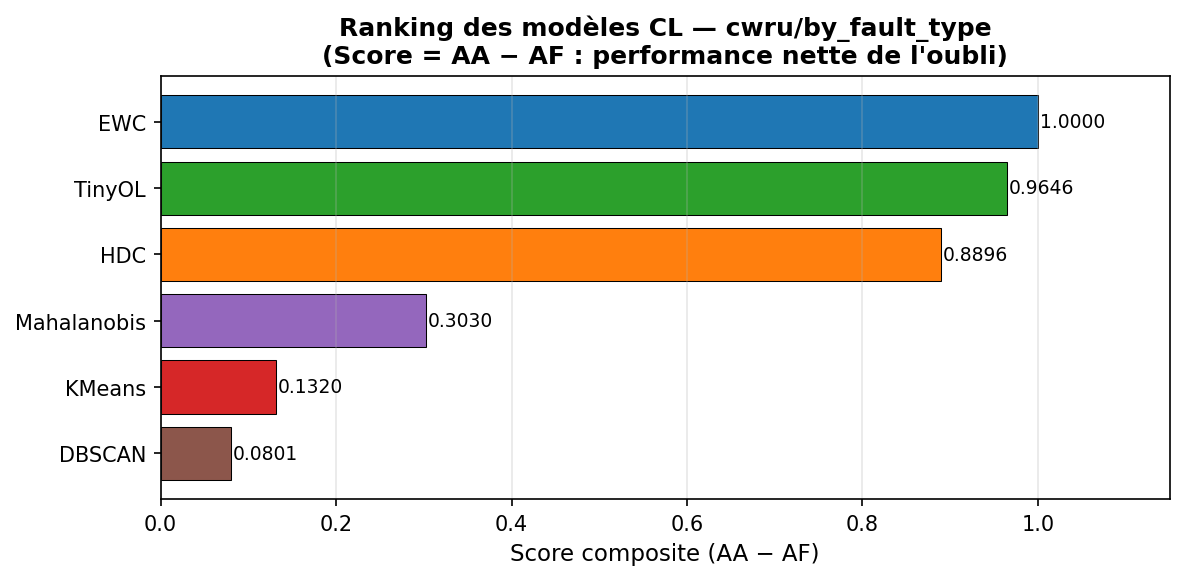

In [5]:
# Section 5 — Ranking des modèles par score composite (AA − AF) → ranking_models.png

scores = {model: results[model]["aa"] - results[model]["af"] for model in MODEL_ORDER}
sorted_models = sorted(scores, key=scores.get, reverse=True)
sorted_scores = [scores[m] for m in sorted_models]

RANK_COLORS = {
    "EWC":         "#1f77b4",
    "HDC":         "#ff7f0e",
    "TinyOL":      "#2ca02c",
    "KMeans":      "#d62728",
    "Mahalanobis": "#9467bd",
    "DBSCAN":      "#8c564b",
}

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [RANK_COLORS[m] for m in sorted_models]
bars = ax.barh(sorted_models, sorted_scores, color=colors_bar, edgecolor="black", linewidth=0.5)

for bar, score in zip(bars, sorted_scores):
    ax.text(
        score + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{score:.4f}", va="center", ha="left", fontsize=9,
    )

ax.set_xlabel("Score composite (AA − AF)", fontsize=11)
ax.set_title(
    "Ranking des modèles CL — cwru/by_fault_type\n(Score = AA − AF : performance nette de l'oubli)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max(sorted_scores) * 1.15)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "ranking_models.png")
display(Image(str(FIGURES_DIR / "ranking_models.png")))

In [6]:
# Section 6 — Comparaison avec baseline single-task (exp_068–073)
# Delta AA = AA_CL − acc_single_task

display(Markdown("### Comparaison CL vs Baseline single-task (cwru/by_fault_type)"))

header = "| Modèle | Baseline ST (acc) | AA CL | Delta AA | AF CL |"
sep    = "|--------|:-----------------:|:-----:|:--------:|:-----:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    r     = results[model]
    bst   = baselines.get(model, float("nan"))
    delta = r["aa"] - bst if not (isinstance(bst, float) and bst != bst) else float("nan")
    bst_s   = f"{bst:.4f}"   if not (isinstance(bst, float) and bst != bst) else "—"
    delta_s = f"{delta:+.4f}" if not (isinstance(delta, float) and delta != delta) else "—"
    sign = "↑" if isinstance(delta, float) and delta == delta and delta >= 0 else "↓"
    rows.append(
        f"| {model} | {bst_s} | {r['aa']:.4f} | {delta_s} {sign} | {r['af']:.4f} |"
    )

display(Markdown("\n".join(rows)))

print("\nNote : Delta AA > 0 indique que le modèle CL surpasse la baseline single-task.")
print("       Delta AA < 0 indique une perte due au scénario multi-tâche.")
print("\nCritères d'acceptation (S12-07) :")
for fig_name in ["comparison_aa_af_bwt.png", "scatter_af_vs_ram.png", "ranking_models.png"]:
    p = FIGURES_DIR / fig_name
    print(f"  [{'OK' if p.exists() else 'MANQUANTE'}] {fig_name}")

### Comparaison CL vs Baseline single-task (cwru/by_fault_type)

| Modèle | Baseline ST (acc) | AA CL | Delta AA | AF CL |
|--------|:-----------------:|:-----:|:--------:|:-----:|
| EWC | 0.9783 | 1.0000 | +0.0217 ↑ | 0.0000 |
| HDC | 0.8870 | 0.9351 | +0.0481 ↑ | 0.0455 |
| TinyOL | 0.9000 | 0.9664 | +0.0664 ↑ | 0.0019 |
| KMeans | 0.1587 | 0.1515 | -0.0072 ↓ | 0.0195 |
| Mahalanobis | 0.1391 | 0.3160 | +0.1769 ↑ | 0.0130 |
| DBSCAN | 0.1457 | 0.1255 | -0.0201 ↓ | 0.0455 |


Note : Delta AA > 0 indique que le modèle CL surpasse la baseline single-task.
       Delta AA < 0 indique une perte due au scénario multi-tâche.

Critères d'acceptation (S12-07) :
  [OK] comparison_aa_af_bwt.png
  [OK] scatter_af_vs_ram.png
  [OK] ranking_models.png
